In [2]:
import pandas as pd

dataset = pd.read_csv(r"https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv")
dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
dataset.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [5]:
dataset.describe(include = object)

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [8]:
dataset.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

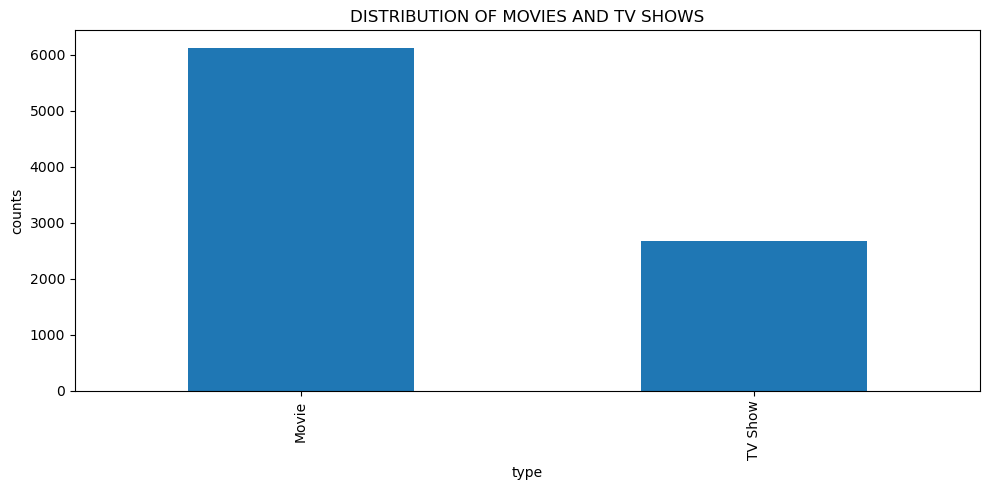

In [18]:
plt.figure(figsize=(10,5))
dataset['type'].value_counts().plot(kind = 'bar')
plt.title('DISTRIBUTION OF MOVIES AND TV SHOWS')
plt.xlabel('type')
plt.ylabel('counts')
plt.tight_layout()
plt.show()

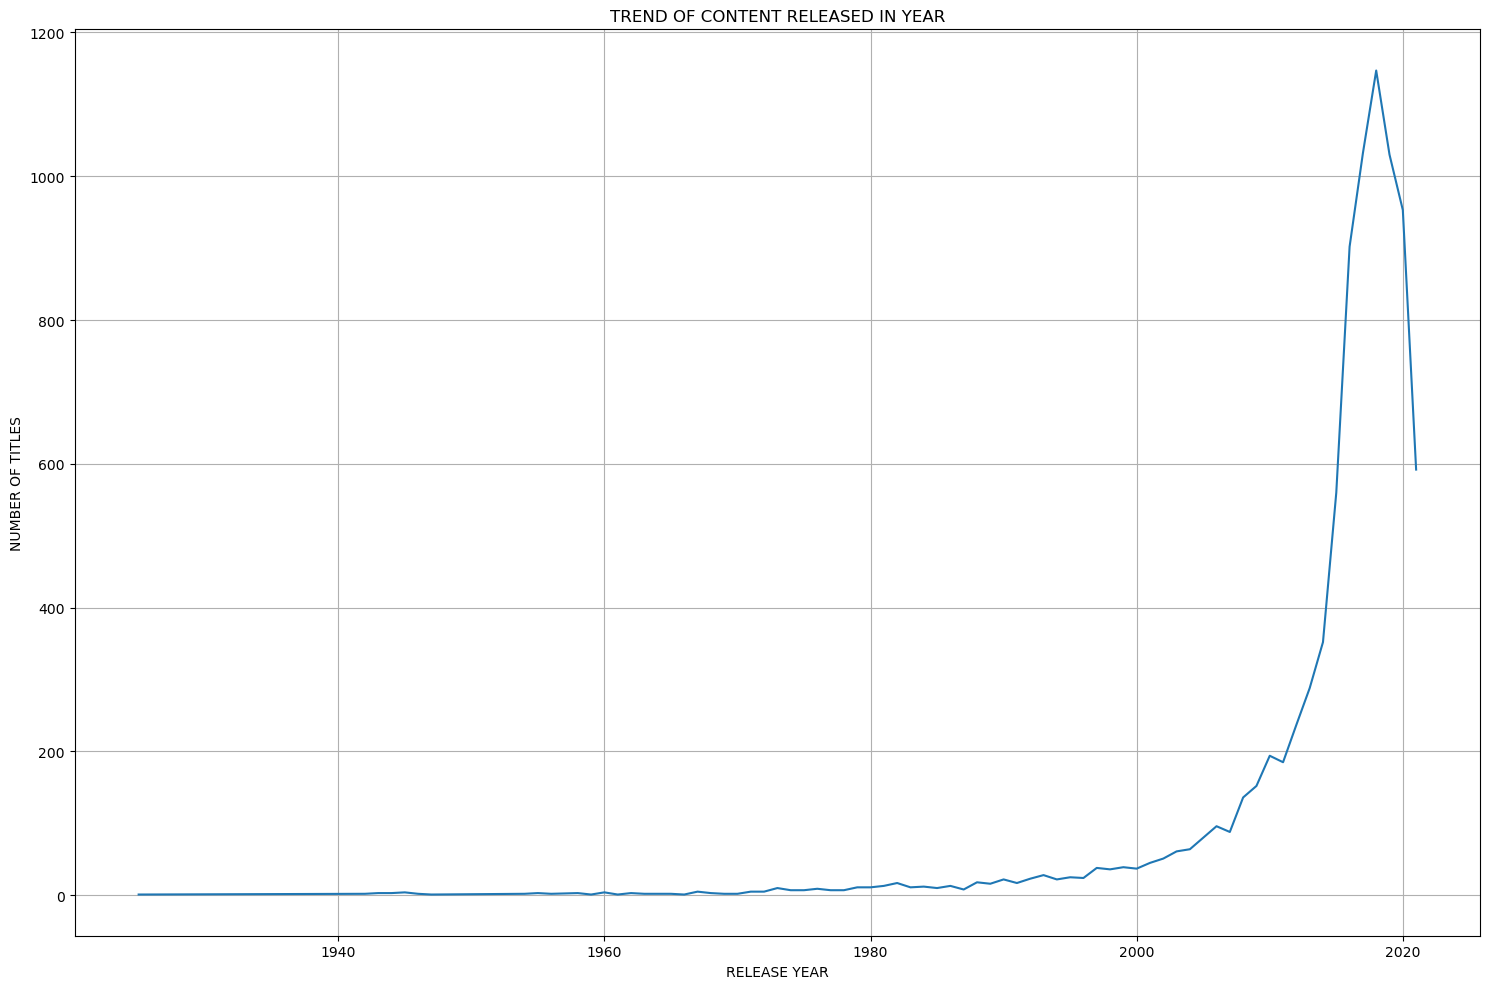

In [26]:
plt.figure(figsize = (15,10))
dataset['release_year'].value_counts().sort_index().plot(kind = 'line')
plt.title('TREND OF CONTENT RELEASED IN YEAR')
plt.xlabel('RELEASE YEAR')
plt.ylabel('NUMBER OF TITLES')
plt.grid(True)
plt.tight_layout()
plt.show()

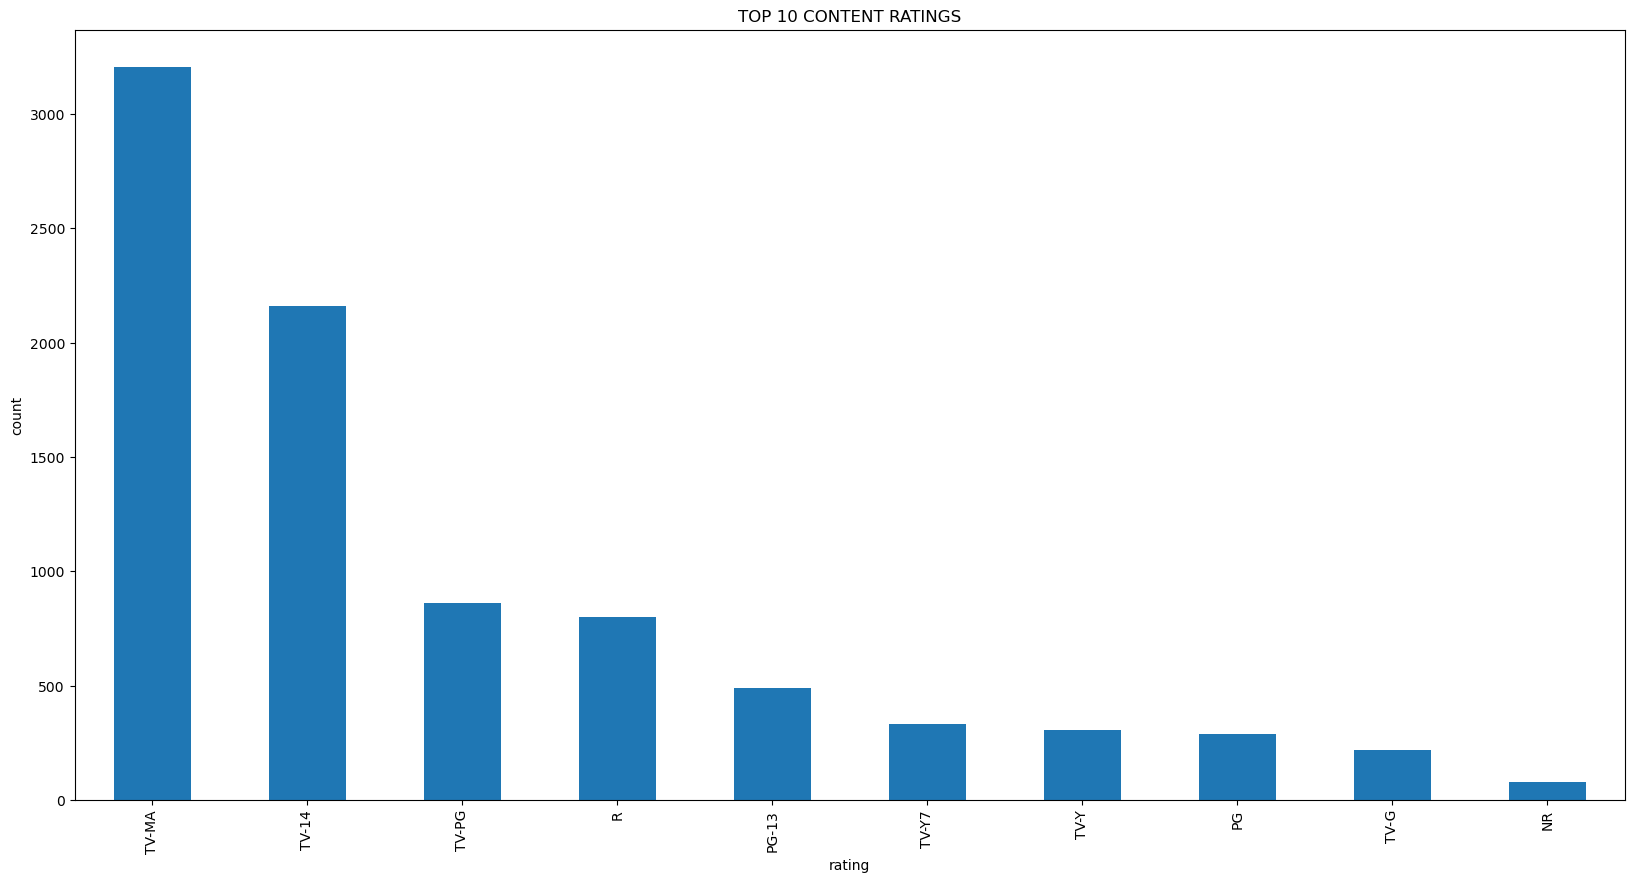

In [30]:
plt.figure(figsize = (20,10))
dataset['rating'].value_counts().head(10).plot(kind = 'bar')
plt.title('TOP 10 CONTENT RATINGS')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()

In [31]:
dataset['country'] = dataset['country'].fillna('unknown')
top_countries = dataset['country'].str.split(',').explode().str.strip().value_counts().head(10)
top_countries.head()
                                               

country
United States     3690
India             1046
unknown            831
United Kingdom     806
Canada             445
Name: count, dtype: int64

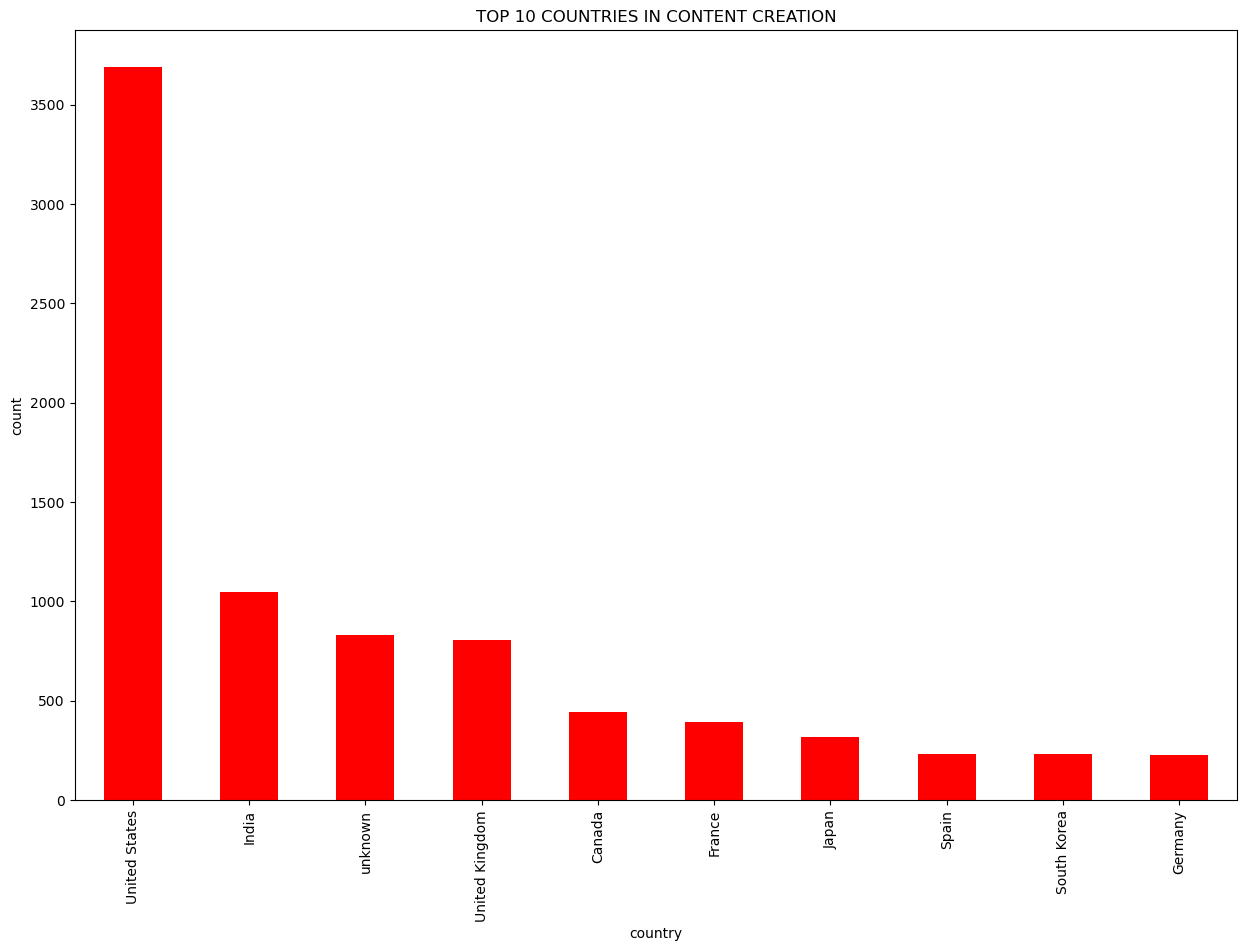

In [34]:
plt.figure(figsize = (15,10))
top_countries.plot(kind = 'bar' ,color = 'red')
plt.title('TOP 10 COUNTRIES IN CONTENT CREATION')
plt.xlabel('country')
plt.ylabel('count')
plt.show()
    

In [36]:
top_genres = dataset['listed_in'].str.split(',' ,expand = True).stack().value_counts().head(10)
top_genres.head()

 International Movies    2624
Dramas                   1600
Comedies                 1210
Action & Adventure        859
Documentaries             829
Name: count, dtype: int64

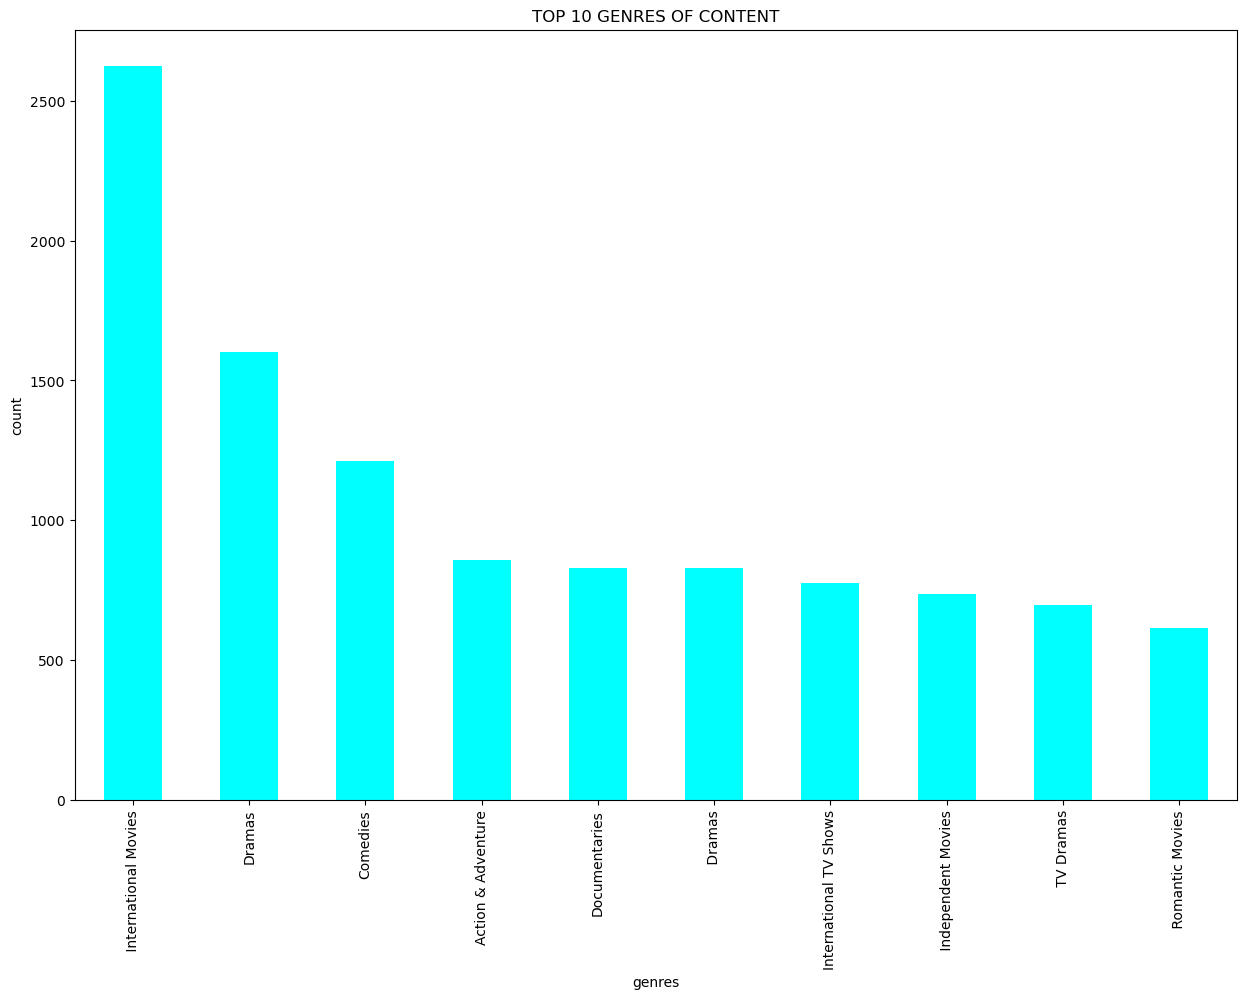

In [39]:
plt.figure(figsize = (15,10))
top_genres.plot(kind = 'bar' ,color = 'cyan')
plt.title('TOP 10 GENRES OF CONTENT')
plt.xlabel('genres')
plt.ylabel('count')
plt.show()